# Test notebook


In [1]:
%load_ext autoreload
%autoreload 2

import os

WORKING_DIR = "/home/andrea/dev/DL/Vit_from_scratch"

if os.getcwd() != WORKING_DIR:
    os.chdir(WORKING_DIR)
    print(f"Working directory cambiata a: {os.getcwd()}")
else:
    print("Working directory già corretta:", os.getcwd())


Working directory cambiata a: /home/andrea/dev/DL/Vit_from_scratch


In [2]:
from utils.device import get_device

In [3]:
get_device()

Device: cuda
GPU: NVIDIA GeForce RTX 2060


device(type='cuda')

## Image managment and conversion to tensors


In [4]:
from data.dataset import get_transforms,get_dataset,print_class_distribution,train_split,verify_unique_data,plotbatch

In [5]:
ds_folder = "data/imagenet-100"

## get the datasets
train_ds = get_dataset(f"{ds_folder}/train",get_transforms(224,"train"))
val_ds = get_dataset(f"{ds_folder}/train",get_transforms(224,"val"))
print(f"Train dataset has {train_ds.classes}")

total_samples = len(train_ds)
print(f"Total samples: {total_samples}")


## 90-10 split for obtaining validation test
train_ds,val_ds = train_split(train_ds,val_ds,0.1)

print(len(train_ds))
print(len(val_ds))
verify_unique_data(train_ds,val_ds)


## get the test set
test_ds = get_dataset(f"{ds_folder}/val.X",get_transforms(224,"test"))


print("\nTotal validation classes are ",len(test_ds.classes))
print("Test_set total examples" , len(test_ds))
print_class_distribution(test_ds,"Test")

Train dataset has ['n01440764', 'n01443537', 'n01484850', 'n01491361', 'n01494475', 'n01496331', 'n01498041', 'n01514668', 'n01514859', 'n01531178', 'n01537544', 'n01560419', 'n01582220', 'n01592084', 'n01601694', 'n01608432', 'n01614925', 'n01622779', 'n01630670', 'n01632458', 'n01632777', 'n01644900', 'n01664065', 'n01665541', 'n01667114', 'n01667778', 'n01675722', 'n01677366', 'n01685808', 'n01687978', 'n01693334', 'n01695060', 'n01698640', 'n01728572', 'n01729322', 'n01729977', 'n01734418', 'n01735189', 'n01739381', 'n01740131', 'n01742172', 'n01749939', 'n01751748', 'n01753488', 'n01755581', 'n01756291', 'n01770081', 'n01770393', 'n01773157', 'n01773549', 'n01773797', 'n01774384', 'n01774750', 'n01775062', 'n01776313', 'n01795545', 'n01796340', 'n01798484', 'n01806143', 'n01818515', 'n01819313', 'n01820546', 'n01824575', 'n01828970', 'n01829413', 'n01833805', 'n01843383', 'n01847000', 'n01855672', 'n01860187', 'n01877812', 'n01883070', 'n01910747', 'n01914609', 'n01924916', 'n0193

Now we instatiate the data loaders

In [6]:
from torch.utils.data import DataLoader

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds,batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [7]:
for images, labels in train_loader:
    print(images.shape)
    break

torch.Size([16, 3, 224, 224])


In [8]:
images[1][0]

tensor([[-0.3712, -0.3541, -0.2856,  ..., -0.7993, -0.7993, -0.7650],
        [-0.3541, -0.3198, -0.1657,  ..., -0.8335, -0.8335, -0.8335],
        [-0.3369, -0.2171, -0.0629,  ..., -0.8335, -0.8678, -0.8507],
        ...,
        [-0.3198, -0.2856, -0.1828,  ..., -0.7822, -0.6965, -0.5596],
        [-0.3541, -0.2684, -0.1486,  ..., -0.5938, -0.5253, -0.4568],
        [-0.3198, -0.2171, -0.1486,  ..., -0.5596, -0.5082, -0.4911]])

We verify if the data loader contains all the classes and also we verify if they are linked correctly to the rights literals (we use Labels.json)

In [9]:
class_names = train_loader.dataset.dataset.classes

import json
with open('data/imagenet-100/Labels.json', 'r') as f:
    dict_to_label = json.load(f)
literal_label = [dict_to_label.get(label,"Errore") for label in class_names]
print(literal_label,len(literal_label))

['tench, Tinca tinca', 'goldfish, Carassius auratus', 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', 'tiger shark, Galeocerdo cuvieri', 'hammerhead, hammerhead shark', 'electric ray, crampfish, numbfish, torpedo', 'stingray', 'cock', 'hen', 'goldfinch, Carduelis carduelis', 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', 'bulbul', 'magpie', 'chickadee', 'water ouzel, dipper', 'kite', 'bald eagle, American eagle, Haliaeetus leucocephalus', 'great grey owl, great gray owl, Strix nebulosa', 'common newt, Triturus vulgaris', 'spotted salamander, Ambystoma maculatum', 'axolotl, mud puppy, Ambystoma mexicanum', 'tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui', 'loggerhead, loggerhead turtle, Caretta caretta', 'leatherback turtle, leatherback, leathery turtle, Dermochelys coriacea', 'mud turtle', 'terrapin', 'banded gecko', 'common iguana, iguana, Iguana iguana', 'whiptail, whiptail lizard', 'agama', 'green lizard, Lacert

# inspect right mapping and annotation for test dataset


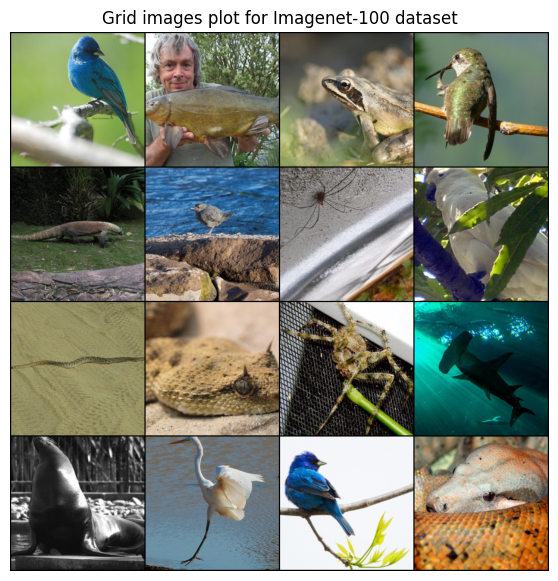

tensor([10,  0, 21, 65, 31, 14, 46, 60, 44, 43, 49,  4, 99, 90, 10, 40]) 16
['n01537544', 'n01440764', 'n01644900', 'n01833805', 'n01695060', 'n01601694', 'n01770081', 'n01819313', 'n01755581', 'n01753488', 'n01773549', 'n01494475', 'n02077923', 'n02012849', 'n01537544', 'n01742172']
['indigo bunting, indigo finch, indigo bird, Passerina cyanea', 'tench, Tinca tinca', 'tailed frog, bell toad, ribbed toad, tailed toad, Ascaphus trui', 'hummingbird', 'Komodo dragon, Komodo lizard, dragon lizard, giant lizard, Varanus komodoensis', 'water ouzel, dipper', 'harvestman, daddy longlegs, Phalangium opilio', 'sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita', 'diamondback, diamondback rattlesnake, Crotalus adamanteus', 'horned viper, cerastes, sand viper, horned asp, Cerastes cornutus', 'barn spider, Araneus cavaticus', 'hammerhead, hammerhead shark', 'sea lion', 'crane', 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', 'boa constrictor, Constrictor constrictor']


In [10]:
test_loader_classes = test_ds.classes
num_images = 16
img_labels = plotbatch(test_loader,batch_size=16,title="Grid images plot for Imagenet-100 dataset",num_images=num_images)
print(img_labels,len(img_labels))
label_names = [test_loader_classes[label.item()] for label in img_labels]
print(label_names)
import json
with open('data/imagenet-100/Labels.json', 'r') as f:
    dict_to_label = json.load(f)
    images_literal_labels = [dict_to_label.get(label,"Errore") for label in label_names]
print(images_literal_labels)

for train dataset

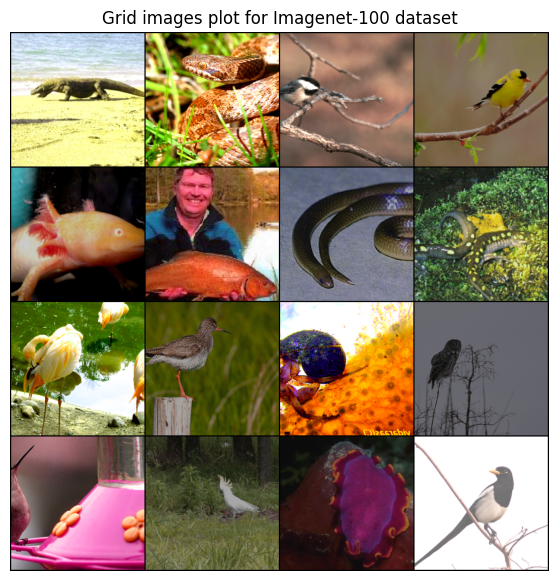

tensor([31, 39, 13,  9, 20,  0, 33, 18, 88, 95, 85, 17, 65, 60, 74, 12]) 16
['n01695060', 'n01740131', 'n01592084', 'n01531178', 'n01632777', 'n01440764', 'n01728572', 'n01630670', 'n02007558', 'n02028035', 'n01986214', 'n01622779', 'n01833805', 'n01819313', 'n01924916', 'n01582220']
['Komodo dragon, Komodo lizard, dragon lizard, giant lizard, Varanus komodoensis', 'night snake, Hypsiglena torquata', 'chickadee', 'goldfinch, Carduelis carduelis', 'axolotl, mud puppy, Ambystoma mexicanum', 'tench, Tinca tinca', 'thunder snake, worm snake, Carphophis amoenus', 'common newt, Triturus vulgaris', 'flamingo', 'redshank, Tringa totanus', 'hermit crab', 'great grey owl, great gray owl, Strix nebulosa', 'hummingbird', 'sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita', 'flatworm, platyhelminth', 'magpie'] 16


In [ ]:
num_images = 16
img_labels = plotbatch(train_loader,batch_size=16,title="Grid images plot for Imagenet-100 dataset Training",num_images=num_images)
print(img_labels,len(img_labels))
label_names = [class_names[label.item()] for label in img_labels]
print(label_names)
import json
with open('data/imagenet-100/Labels.json', 'r') as f:
    dict_to_label = json.load(f)
    images_literal_labels = [dict_to_label.get(label,"Errore") for label in label_names]
print(images_literal_labels,len(images_literal_labels))